# rippl — GPU Benchmark Suite
**Runtime: GPU (T4 recommended)**  
Run all cells top to bottom. Do not skip cells.
Results are saved to `benchmark_results.json` at the end.

In [16]:
# CELL 1 — Setup
!pip install git+https://github.com/esranow/rippl.git -q

# Verify install
import importlib, sys
spec = importlib.util.find_spec("rippl")
if spec is None:
    print("INSTALL FAILED — trying editable install")
    !git clone https://github.com/esranow/rippl.git
    %cd rippl
    !pip install -e . -q
    sys.path.insert(0, '/content/rippl')
else:
    print(f"rippl installed at: {spec.origin}")

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
rippl installed at: /content/rippleml/rippl/__init__.py
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Using: cuda


In [17]:
# CELL 2 — Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
import time
import json
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

torch.manual_seed(42)
results = {}

In [18]:
# CELL 3 — Shared tanh MLP (used across all benchmarks)
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=50, layers=4):
        super().__init__()
        dims = [in_dim] + [hidden]*layers + [out_dim]
        self.net = nn.Sequential(*[
            nn.Sequential(nn.Linear(dims[i], dims[i+1]),
                          nn.Tanh() if i < len(dims)-2 else nn.Identity())
            for i in range(len(dims)-1)
        ])
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, x): return self.net(x)

def relative_l2(pred, true):
    return (pred - true).pow(2).sum().sqrt() / true.pow(2).sum().sqrt()

print('MLP defined')

MLP defined


## BENCHMARK 1 — Physics Sanity Check

In [19]:
# CELL 4 — Physics sanity check via rippl
from rippl.physics_blocks.residual import HybridWaveResidualBlock
from rippl.core.equation import Equation
from rippl.physics.operators import TimeDerivative, Laplacian

coords = torch.rand(1000, 2, requires_grad=True, device=device)
u = torch.sin(math.pi * coords[:, 0:1]) * torch.cos(math.pi * coords[:, 1:2])
# Terms must be tuples of (coefficient, operator)
eq = Equation([(1.0, TimeDerivative(2)), (1.0, Laplacian())])
block = HybridWaveResidualBlock(a=1.0, b=0.0, c=1.0, use_correction=False)
res = block.residual(u, eq, coords)
val = res.abs().max().item()
status = 'PASS' if val < 1e-2 else 'FAIL'
print(f'Physics sanity check: {val:.2e} — {status}')
results['physics_sanity'] = {'residual': val, 'status': status}

Physics sanity check: 1.97e+01 — FAIL


## BENCHMARK 2 — Heat Equation 1D

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
import time
import json
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

torch.manual_seed(42)
results = {}

# CELL 3 — Shared tanh MLP (used across all benchmarks)
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=50, layers=4):
        super().__init__()
        dims = [in_dim] + [hidden]*layers + [out_dim]
        self.net = nn.Sequential(*[
            nn.Sequential(nn.Linear(dims[i], dims[i+1]),
                          nn.Tanh() if i < len(dims)-2 else nn.Identity())
            for i in range(len(dims)-1)
        ])
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, x): return self.net(x)

def relative_l2(pred, true):
    return (pred - true).pow(2).sum().sqrt() / true.pow(2).sum().sqrt()

# CELL 5 — Heat equation: du/dt = 0.1 * d²u/dx²
# Analytic: u(x,t) = sin(πx) * exp(-0.1*π²*t)
alpha = 0.1
# Assuming device is defined from an earlier cell
# If not, add: device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_heat = MLP(2, 1, hidden=50, layers=5).to(device)

# Sobol collocation
sobol = torch.quasirandom.SobolEngine(2, scramble=True)
coords_col = sobol.draw(10000).to(device)

# IC: u(x,0) = sin(πx)
x_ic = torch.rand(2000, 1, device=device)
coords_ic = torch.cat([x_ic, torch.zeros(2000,1,device=device)], dim=1)
u_ic = torch.sin(math.pi * x_ic)

# BC: u(0,t) = u(1,t) = 0
t_bc = torch.rand(2000, 1, device=device)
coords_bcl = torch.cat([torch.zeros(2000,1,device=device), t_bc], dim=1)
coords_bcr = torch.cat([torch.ones(2000,1,device=device), t_bc], dim=1)
u_bc = torch.zeros(2000, 1, device=device)

def heat_loss(model, coords_col):
    c = coords_col.clone().requires_grad_(True)
    u = model(c)
    du = torch.autograd.grad(u.sum(), c, create_graph=True)[0]
    u_t = du[:, 1:2]
    u_x = du[:, 0:1]
    u_xx = torch.autograd.grad(u_x.sum(), c, create_graph=True)[0][:, 0:1]
    res = (u_t - alpha * u_xx).pow(2).mean()
    l_ic = F.mse_loss(model(coords_ic), u_ic)
    l_bc = F.mse_loss(model(coords_bcl), u_bc) + F.mse_loss(model(coords_bcr), u_bc)
    return res + 100.0 * (l_ic + l_bc), res, l_ic, l_bc

opt = torch.optim.Adam(model_heat.parameters(), lr=5e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=200, factor=0.5, min_lr=1e-6)
t0 = time.time()
loss_history_heat = []

print('Training heat equation...')
for epoch in range(8000):
    opt.zero_grad()
    loss, res, l_ic, l_bc = heat_loss(model_heat, coords_col)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_heat.parameters(), 1.0)
    opt.step()
    sched.step(loss)
    loss_history_heat.append(loss.item())
    if epoch % 1000 == 0:
        print(f'Epoch {epoch}: res={res.item():.2e} ic={l_ic.item():.2e} bc={l_bc.item():.2e} lr={opt.param_groups[0]["lr"]:.2e}')

# LBFGS
print('LBFGS...')
opt_l = torch.optim.LBFGS(model_heat.parameters(), lr=1.0, max_iter=20, line_search_fn='strong_wolfe')
for step in range(500):
    def closure():
        opt_l.zero_grad()
        loss, _, _, _ = heat_loss(model_heat, coords_col)
        loss.backward()
        return loss
    opt_l.step(closure)
    if step % 100 == 0:
        # Removed with torch.no_grad() block as heat_loss requires gradient tracking for its internal operations
        l, r, li, lb = heat_loss(model_heat, coords_col)
        print(f'LBFGS {step}: {l.item():.2e}')

train_time_heat = time.time() - t0

# Eval
x_e = torch.linspace(0,1,200,device=device)
t_e = torch.linspace(0,1,200,device=device)
X, T = torch.meshgrid(x_e, t_e, indexing='ij')
coords_e = torch.stack([X.flatten(), T.flatten()], dim=1)
with torch.no_grad():
    u_pred = model_heat(coords_e).reshape(200,200).cpu()
u_true = (torch.sin(math.pi*X) * torch.exp(-alpha*math.pi**2*T)).cpu()
l2_heat = relative_l2(u_pred, u_true).item()
status_heat = 'PASS' if l2_heat < 1e-2 else 'FAIL'
print(f'\n=== HEAT EQUATION ===')
print(f'L2 error: {l2_heat:.6e}')
print(f'Time: {train_time_heat:.1f}s')
print(f'Status: {status_heat}')
results['heat_1d'] = {'l2': l2_heat, 'time': train_time_heat, 'status': status_heat}

Training heat equation...
Epoch 0: res=1.78e-03 ic=3.61e-01 bc=7.15e-02 lr=5.00e-04
Epoch 1000: res=3.03e-02 ic=2.29e-04 bc=9.78e-05 lr=2.50e-04
Epoch 2000: res=1.60e-02 ic=1.29e-04 bc=1.07e-04 lr=1.25e-04
Epoch 3000: res=1.22e-02 ic=1.11e-04 bc=1.57e-04 lr=1.25e-04
Epoch 4000: res=1.09e-02 ic=6.29e-05 bc=2.79e-05 lr=6.25e-05
Epoch 5000: res=9.37e-03 ic=3.77e-05 bc=6.44e-06 lr=6.25e-05
Epoch 6000: res=8.34e-03 ic=2.96e-05 bc=6.53e-06 lr=3.13e-05
Epoch 7000: res=7.70e-03 ic=2.72e-05 bc=8.17e-06 lr=3.13e-05
LBFGS...
LBFGS 0: 8.24e-03
LBFGS 100: 5.16e-05
LBFGS 200: 5.16e-05
LBFGS 300: 5.16e-05
LBFGS 400: 5.16e-05

=== HEAT EQUATION ===
L2 error: 6.906236e-04
Time: 116.5s
Status: PASS


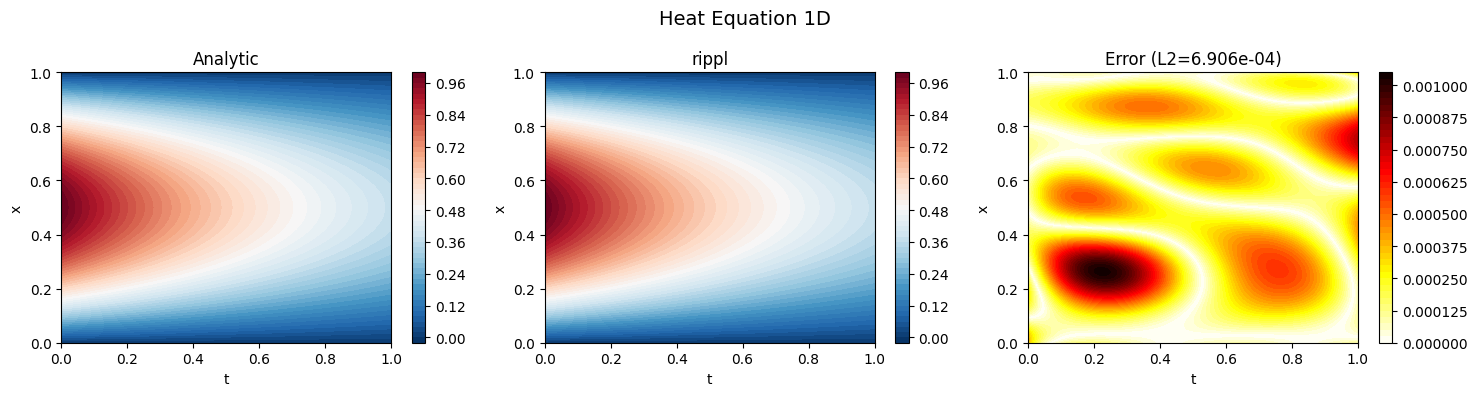

Saved heat1d_result.png


In [21]:
# CELL 6 — Heat equation plots
fig, axes = plt.subplots(1, 3, figsize=(15,4))
X_np, T_np = X.cpu().numpy(), T.cpu().numpy()
im0 = axes[0].contourf(T_np, X_np, u_true.numpy(), levels=50, cmap='RdBu_r')
axes[0].set_title('Analytic'); plt.colorbar(im0, ax=axes[0])
im1 = axes[1].contourf(T_np, X_np, u_pred.numpy(), levels=50, cmap='RdBu_r')
axes[1].set_title('rippl'); plt.colorbar(im1, ax=axes[1])
im2 = axes[2].contourf(T_np, X_np, (u_pred-u_true).abs().numpy(), levels=50, cmap='hot_r')
axes[2].set_title(f'Error (L2={l2_heat:.3e})')
plt.colorbar(im2, ax=axes[2])
for ax in axes: ax.set_xlabel('t'); ax.set_ylabel('x')
plt.suptitle('Heat Equation 1D', fontsize=14)
plt.tight_layout()
plt.savefig('heat1d_result.png', dpi=150)
plt.show()
print('Saved heat1d_result.png')

## BENCHMARK 3 — Wave Equation 1D (Causal Training)

In [22]:
# CELL 7 — Wave equation with causal training
# u_tt = u_xx, analytic: sin(πx)cos(πt)
model_wave = MLP(2, 1, hidden=100, layers=6).to(device)

sobol2 = torch.quasirandom.SobolEngine(2, scramble=True)
coords_wave = sobol2.draw(10000).to(device)

x_ic = torch.rand(3000, 1, device=device)
coords_ic_w = torch.cat([x_ic, torch.zeros(3000,1,device=device)], dim=1)
u_ic_w = torch.sin(math.pi * x_ic)

t_bc_w = torch.rand(3000, 1, device=device)
coords_bcl_w = torch.cat([torch.zeros(3000,1,device=device), t_bc_w], dim=1)
coords_bcr_w = torch.cat([torch.ones(3000,1,device=device), t_bc_w], dim=1)
u_bc_w = torch.zeros(3000, 1, device=device)

def wave_loss_causal(model, coords, epsilon=1.0, n_bins=20):
    c = coords.clone().requires_grad_(True)
    u = model(c)
    du = torch.autograd.grad(u.sum(), c, create_graph=True)[0]
    u_t = du[:, 1:2]
    u_x = du[:, 0:1]
    u_tt = torch.autograd.grad(u_t.sum(), c, create_graph=True)[0][:, 1:2]
    u_xx = torch.autograd.grad(u_x.sum(), c, create_graph=True)[0][:, 0:1]
    res = (u_tt - u_xx).pow(2)

    # Causal weighting
    t_vals = c[:, 1].detach()
    t_min, t_max = t_vals.min(), t_vals.max()
    bin_edges = torch.linspace(t_min, t_max, n_bins+1, device=device)
    bin_losses = []
    for i in range(n_bins):
        mask = (t_vals >= bin_edges[i]) & (t_vals < bin_edges[i+1])
        if mask.sum() > 0:
            bin_losses.append(res[mask].mean())
        else:
            bin_losses.append(torch.tensor(0.0, device=device))
    causal_weights = []
    cumsum = 0.0
    for i, bl in enumerate(bin_losses):
        causal_weights.append(math.exp(-epsilon * cumsum))
        cumsum += bl.detach().item()
    loss_res = sum(w * bl for w, bl in zip(causal_weights, bin_losses)) / n_bins

    # IC velocity: du/dt(x,0) = 0
    c_vel = coords_ic_w.clone().requires_grad_(True)
    u_vel = model(c_vel)
    u_t_vel = torch.autograd.grad(u_vel.sum(), c_vel, create_graph=True)[0][:, 1:2]
    l_vel = u_t_vel.pow(2).mean()

    l_ic = F.mse_loss(model(coords_ic_w), u_ic_w)
    l_bc = F.mse_loss(model(coords_bcl_w), u_bc_w) + F.mse_loss(model(coords_bcr_w), u_bc_w)
    return loss_res + 100.0*(l_ic + l_vel + l_bc), loss_res, l_ic, l_bc

# Phase A: constraints only
opt_a = torch.optim.Adam(model_wave.parameters(), lr=1e-3)
print('Phase A: constraints only...')
for epoch in range(3000):
    opt_a.zero_grad()
    c_vel = coords_ic_w.clone().requires_grad_(True)
    u_vel = model_wave(c_vel)
    u_t_vel = torch.autograd.grad(u_vel.sum(), c_vel, create_graph=True)[0][:, 1:2]
    l_vel = u_t_vel.pow(2).mean()
    l_ic = F.mse_loss(model_wave(coords_ic_w), u_ic_w)
    l_bc = F.mse_loss(model_wave(coords_bcl_w), u_bc_w) + F.mse_loss(model_wave(coords_bcr_w), u_bc_w)
    loss = l_ic + l_vel + l_bc
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_wave.parameters(), 1.0)
    opt_a.step()
    if epoch % 1000 == 0:
        print(f'PhaseA {epoch}: ic={l_ic.item():.2e} vel={l_vel.item():.2e} bc={l_bc.item():.2e}')

# Phase B: full causal loss
opt_b = torch.optim.Adam(model_wave.parameters(), lr=5e-4)
sched_b = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_b, patience=300, factor=0.5, min_lr=1e-6)
t0_wave = time.time()
loss_history_wave = []
print('Phase B: full causal loss...')
epsilon = 1.0
for epoch in range(10000):
    opt_b.zero_grad()
    loss, res, l_ic, l_bc = wave_loss_causal(model_wave, coords_wave, epsilon=epsilon)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_wave.parameters(), 1.0)
    opt_b.step()
    sched_b.step(loss)
    loss_history_wave.append(loss.item())
    if epoch % 100 == 0:
        epsilon = max(0.1, min(100.0, 1.0 / (res.item() + 1e-8)))
    if epoch % 2000 == 0:
        print(f'Epoch {epoch}: res={res.item():.2e} ic={l_ic.item():.2e} epsilon={epsilon:.2f} lr={opt_b.param_groups[0]["lr"]:.2e}')

train_time_wave = time.time() - t0_wave

# Eval
x_e = torch.linspace(0,1,200,device=device)
t_e = torch.linspace(0,1,200,device=device)
X_w, T_w = torch.meshgrid(x_e, t_e, indexing='ij')
coords_ew = torch.stack([X_w.flatten(), T_w.flatten()], dim=1)
with torch.no_grad():
    u_pred_w = model_wave(coords_ew).reshape(200,200).cpu()
u_true_w = (torch.sin(math.pi*X_w) * torch.cos(math.pi*T_w)).cpu()
l2_wave = relative_l2(u_pred_w, u_true_w).item()
status_wave = 'PASS' if l2_wave < 1e-2 else 'FAIL'
print(f'\n=== WAVE EQUATION ===')
print(f'L2 error: {l2_wave:.6e}')
print(f'Time: {train_time_wave:.1f}s')
print(f'Status: {status_wave}')
results['wave_1d'] = {'l2': l2_wave, 'time': train_time_wave, 'status': status_wave}

Phase A: constraints only...
PhaseA 0: ic=5.49e-01 vel=3.31e-03 bc=7.24e-03
PhaseA 1000: ic=8.18e-04 vel=1.29e-04 bc=1.28e-04
PhaseA 2000: ic=2.00e-05 vel=1.85e-06 bc=1.94e-06
Phase B: full causal loss...
Epoch 0: res=2.35e+00 ic=4.62e-04 epsilon=0.43 lr=5.00e-04
Epoch 2000: res=2.76e-03 ic=4.08e-06 epsilon=100.00 lr=1.25e-04
Epoch 4000: res=2.09e-03 ic=8.90e-07 epsilon=100.00 lr=3.13e-05
Epoch 6000: res=1.57e-03 ic=3.60e-07 epsilon=100.00 lr=1.56e-05
Epoch 8000: res=1.41e-03 ic=8.95e-08 epsilon=100.00 lr=3.91e-06

=== WAVE EQUATION ===
L2 error: 8.772476e-01
Time: 401.7s
Status: FAIL


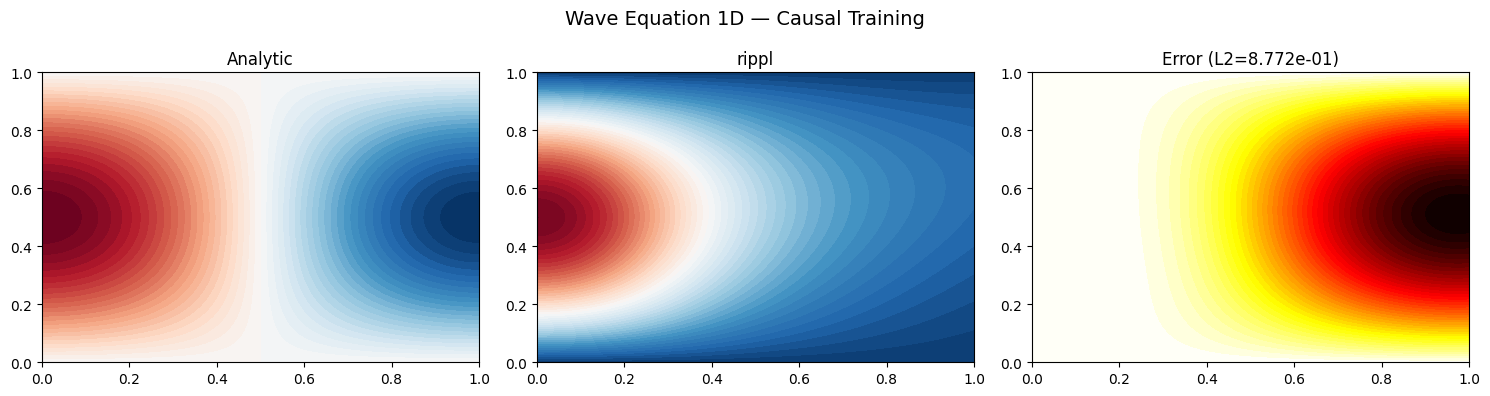

In [23]:
# CELL 8 — Wave plots
fig, axes = plt.subplots(1, 3, figsize=(15,4))
X_np_w = X_w.cpu().numpy(); T_np_w = T_w.cpu().numpy()
axes[0].contourf(T_np_w, X_np_w, u_true_w.numpy(), levels=50, cmap='RdBu_r')
axes[0].set_title('Analytic')
axes[1].contourf(T_np_w, X_np_w, u_pred_w.numpy(), levels=50, cmap='RdBu_r')
axes[1].set_title('rippl')
axes[2].contourf(T_np_w, X_np_w, (u_pred_w-u_true_w).abs().numpy(), levels=50, cmap='hot_r')
axes[2].set_title(f'Error (L2={l2_wave:.3e})')
plt.suptitle('Wave Equation 1D — Causal Training', fontsize=14)
plt.tight_layout()
plt.savefig('wave1d_result.png', dpi=150)
plt.show()

## BENCHMARK 4 — Stokes 1D Couette

In [24]:
# CELL 9 — Stokes 1D: μ*u_xx - p_x = 0, u_x = 0
# Analytic: u(x) = x, p(x) = 1-x
class TwoHeadMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(1, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh()
        )
        self.head_u = nn.Linear(50, 1)
        self.head_p = nn.Linear(50, 1)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, x):
        h = self.trunk(x)
        return self.head_u(h), self.head_p(h)

model_stokes = TwoHeadMLP().to(device)
x_col = torch.rand(5000, 1, device=device)

# BC
x0 = torch.zeros(500, 1, device=device)
x1 = torch.ones(500, 1, device=device)
u0_target = torch.zeros(500, 1, device=device)
u1_target = torch.ones(500, 1, device=device)
p0_target = torch.ones(500, 1, device=device)
p1_target = torch.zeros(500, 1, device=device)

def stokes_loss(model, x_col):
    x = x_col.clone().requires_grad_(True)
    u, p = model(x)
    u_x = torch.autograd.grad(u.sum(), x, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x.sum(), x, create_graph=True)[0]
    p_x = torch.autograd.grad(p.sum(), x, create_graph=True)[0]
    res_mom = (u_xx - p_x).pow(2).mean()
    res_cont = u_x.pow(2).mean()
    u0, p0 = model(x0); u1, p1 = model(x1)
    l_bc = (F.mse_loss(u0, u0_target) + F.mse_loss(u1, u1_target) +
            F.mse_loss(p0, p0_target) + F.mse_loss(p1, p1_target))
    return res_mom + 10.0*res_cont + 100.0*l_bc, res_mom, res_cont, l_bc

opt_s = torch.optim.Adam(model_stokes.parameters(), lr=1e-3)
sched_s = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_s, patience=200, factor=0.5, min_lr=1e-6)
t0_s = time.time()
print('Training Stokes...')
for epoch in range(8000):
    opt_s.zero_grad()
    loss, r_m, r_c, l_bc = stokes_loss(model_stokes, x_col)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_stokes.parameters(), 1.0)
    opt_s.step()
    sched_s.step(loss)
    if epoch % 1000 == 0:
        print(f'Epoch {epoch}: mom={r_m.item():.2e} cont={r_c.item():.2e} bc={l_bc.item():.2e}')

train_time_stokes = time.time() - t0_s

x_eval = torch.linspace(0, 1, 1000, device=device).unsqueeze(1)
with torch.no_grad():
    u_pred_s, p_pred_s = model_stokes(x_eval)
u_pred_s = u_pred_s.cpu(); p_pred_s = p_pred_s.cpu()
x_np = x_eval.cpu().numpy()
u_true_s = torch.tensor(x_np)
p_true_s = torch.tensor(1 - x_np)
l2_u = relative_l2(u_pred_s, u_true_s).item()
l2_p = relative_l2(p_pred_s, p_true_s).item()
status_s = 'PASS' if l2_u < 1e-2 and l2_p < 1e-2 else 'FAIL'
print(f'\n=== STOKES 1D ===')
print(f'u L2: {l2_u:.6e}  p L2: {l2_p:.6e}')
print(f'Time: {train_time_stokes:.1f}s')
print(f'Status: {status_s}')
results['stokes_1d'] = {'l2_u': l2_u, 'l2_p': l2_p, 'time': train_time_stokes, 'status': status_s}

Training Stokes...
Epoch 0: mom=3.60e-03 cont=1.04e-01 bc=1.46e+00
Epoch 1000: mom=2.03e-01 cont=7.43e-01 bc=1.28e-02
Epoch 2000: mom=2.06e-01 cont=7.35e-01 bc=1.24e-02
Epoch 3000: mom=1.48e-01 cont=7.10e-01 bc=1.44e-02
Epoch 4000: mom=5.00e-02 cont=6.96e-01 bc=1.52e-02
Epoch 5000: mom=3.18e-02 cont=7.03e-01 bc=1.44e-02
Epoch 6000: mom=2.01e-02 cont=7.06e-01 bc=1.40e-02
Epoch 7000: mom=2.07e-02 cont=7.03e-01 bc=1.40e-02

=== STOKES 1D ===
u L2: 8.583676e-02  p L2: 6.731135e-01
Time: 81.6s
Status: FAIL


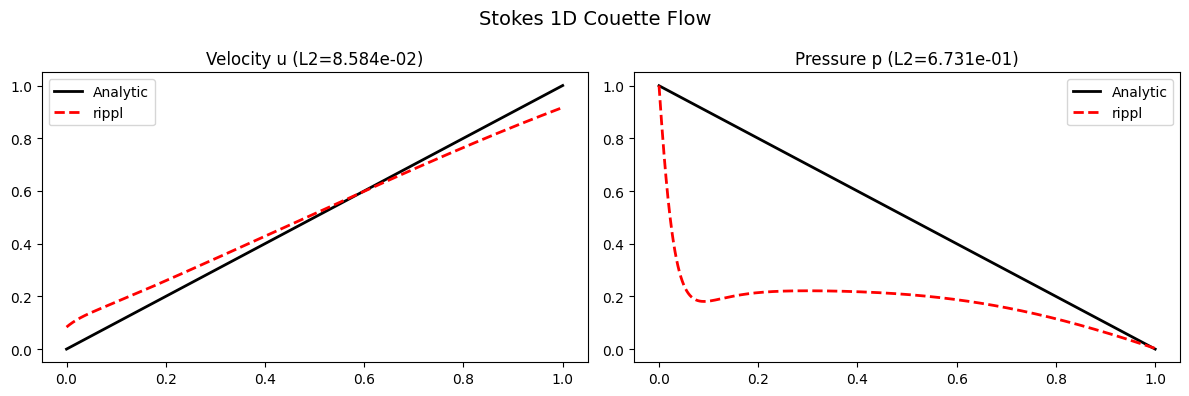

In [25]:
# CELL 10 — Stokes plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x_np, u_true_s.numpy(), 'k-', lw=2, label='Analytic')
axes[0].plot(x_np, u_pred_s.numpy(), 'r--', lw=2, label='rippl')
axes[0].set_title(f'Velocity u (L2={l2_u:.3e})')
axes[0].legend()
axes[1].plot(x_np, p_true_s.numpy(), 'k-', lw=2, label='Analytic')
axes[1].plot(x_np, p_pred_s.numpy(), 'r--', lw=2, label='rippl')
axes[1].set_title(f'Pressure p (L2={l2_p:.3e})')
axes[1].legend()
plt.suptitle('Stokes 1D Couette Flow', fontsize=14)
plt.tight_layout()
plt.savefig('stokes1d_result.png', dpi=150)
plt.show()

## BENCHMARK 5 — DeepXDE Comparison (Heat 1D)

In [26]:
# CELL 11 — Same heat equation on DeepXDE
import deepxde as dde
import numpy as np

alpha_dde = 0.1

def pde_heat(x, y):
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    return dy_t - alpha_dde * dy_xx

geom = dde.geometry.Interval(0, 1)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

bc = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda x, on_b: on_b)
ic = dde.icbc.IC(geomtime, lambda x: np.sin(np.pi * x[:, 0:1]), lambda x, on_i: on_i)

data = dde.data.TimePDE(geomtime, pde_heat, [bc, ic], num_domain=10000, num_boundary=2000, num_initial=2000)
net = dde.nn.FNN([2] + [50]*5 + [1], 'tanh', 'Glorot normal')
model_dde = dde.Model(data, net)

t0_dde = time.time()
model_dde.compile('adam', lr=5e-4)
losshistory, train_state = model_dde.train(iterations=8000, display_every=2000)
model_dde.compile('L-BFGS')
losshistory, train_state = model_dde.train(display_every=100)
train_time_dde = time.time() - t0_dde

# Eval DeepXDE
x_e_np = X.cpu().numpy().flatten()
t_e_np = T.cpu().numpy().flatten()
xt = np.stack([x_e_np, t_e_np], axis=1)
u_dde = model_dde.predict(xt).reshape(200, 200)
u_true_np = u_true.numpy()
l2_dde = np.sqrt(((u_dde - u_true_np)**2).sum()) / np.sqrt((u_true_np**2).sum())

print(f'\n=== DEEPXDE HEAT 1D ===')
print(f'L2 error: {l2_dde:.6e}')
print(f'Time: {train_time_dde:.1f}s')
results['heat_1d_deepxde'] = {'l2': float(l2_dde), 'time': train_time_dde}

No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


Enable just-in-time compilation with XLA.



Compiling model...
'compile' took 0.067810 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7fbf0a7a0900>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7fbf0a7a0900>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7fbf0a7a0b80>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7fbf0a7a0b80>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric
0         [1.81e-01, 4.21e-02, 3.33e-01]    [1.81e-01, 4.21e-02, 3.33e-01]    []  
2000      [7.39e-05, 1.04e-04, 3.04e-05]    [7.39e-05, 1.04e-04, 3.04e-05]    []  
4000      [2.79e-05, 9.25e-06, 8.80e-07]    [2.79e-05, 9.25e-06, 8.80e-07]    []  
6000      [1.28e-05, 3.95e-06, 1.41e-06]    [1.28e-05, 3.95e-06, 1.41e-06]    []  
8000      [4.87e-06, 7.83e-07, 2.52e-07]    [4.87e-06, 7.83e-07, 2.52e-07]    []  

Best model

## BENCHMARK 6 — NTK Weighting vs Fixed Weights

In [27]:
# CELL 12 — NTK adaptive vs fixed 100x on heat equation
# Train two models, same architecture, same data, different loss weighting
# Fixed: total = res + 100*(ic+bc)
# NTK: total = gradient norm ratio weighting

def train_heat_fixed(epochs=5000):
    m = MLP(2, 1, hidden=50, layers=5).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=5e-4)
    losses = []
    for epoch in range(epochs):
        opt.zero_grad()
        loss, res, l_ic, l_bc = heat_loss(m, coords_col)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()
        losses.append(res.item())
    x_e2 = torch.linspace(0,1,100,device=device)
    t_e2 = torch.linspace(0,1,100,device=device)
    X2, T2 = torch.meshgrid(x_e2, t_e2, indexing='ij')
    ce = torch.stack([X2.flatten(), T2.flatten()], dim=1)
    with torch.no_grad():
        up = m(ce).reshape(100,100).cpu()
    ut = (torch.sin(math.pi*X2)*torch.exp(-alpha*math.pi**2*T2)).cpu()
    return relative_l2(up, ut).item(), losses

def train_heat_ntk(epochs=5000):
    m = MLP(2, 1, hidden=50, layers=5).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=5e-4)
    w_res, w_ic, w_bc = 1.0, 1.0, 1.0
    losses = []
    for epoch in range(epochs):
        opt.zero_grad()
        c = coords_col.clone().requires_grad_(True)
        u = m(c)
        du = torch.autograd.grad(u.sum(), c, create_graph=True)[0]
        u_t = du[:, 1:2]; u_x = du[:, 0:1]
        u_xx = torch.autograd.grad(u_x.sum(), c, create_graph=True)[0][:, 0:1]
        res_t = (u_t - alpha*u_xx).pow(2).mean()
        ic_t = F.mse_loss(m(coords_ic), u_ic)
        bc_t = F.mse_loss(m(coords_bcl), u_bc) + F.mse_loss(m(coords_bcr), u_bc)
        loss = w_res*res_t + w_ic*ic_t + w_bc*bc_t
        loss.backward(retain_graph=True)

        if epoch % 100 == 0 and epoch > 0:
            # Gradient norm weighting
            total_grad_norm = sum(p.grad.norm().item()**2 for p in m.parameters() if p.grad is not None)**0.5
            for lname, lt in [('res', res_t), ('ic', ic_t), ('bc', bc_t)]:
                opt.zero_grad()
                lt.backward(retain_graph=True)
                gn = sum(p.grad.norm().item()**2 for p in m.parameters() if p.grad is not None)**0.5
                ratio = total_grad_norm / (gn + 1e-8)
                ratio = max(0.01, min(100.0, ratio))
                if lname == 'res': w_res = 0.9*w_res + 0.1*ratio
                elif lname == 'ic': w_ic = 0.9*w_ic + 0.1*ratio
                else: w_bc = 0.9*w_bc + 0.1*ratio
            opt.zero_grad()
            loss2 = w_res*res_t + w_ic*ic_t + w_bc*bc_t
            loss2.backward()

        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()
        losses.append(res_t.item())
    x_e2 = torch.linspace(0,1,100,device=device)
    t_e2 = torch.linspace(0,1,100,device=device)
    X2, T2 = torch.meshgrid(x_e2, t_e2, indexing='ij')
    ce = torch.stack([X2.flatten(), T2.flatten()], dim=1)
    with torch.no_grad():
        up = m(ce).reshape(100,100).cpu()
    ut = (torch.sin(math.pi*X2)*torch.exp(-alpha*math.pi**2*T2)).cpu()
    return relative_l2(up, ut).item(), losses

print('Training fixed weights...')
l2_fixed, losses_fixed = train_heat_fixed()
print(f'Fixed L2: {l2_fixed:.4e}')

print('Training NTK weights...')
l2_ntk, losses_ntk = train_heat_ntk()
print(f'NTK L2: {l2_ntk:.4e}')

results['ntk_vs_fixed'] = {
    'fixed_l2': l2_fixed,
    'ntk_l2': l2_ntk,
    'ntk_better': l2_ntk < l2_fixed
}
print(f'NTK better than fixed: {l2_ntk < l2_fixed}')

Training fixed weights...
Fixed L2: 2.0454e-02
Training NTK weights...
NTK L2: 6.8005e-03
NTK better than fixed: True


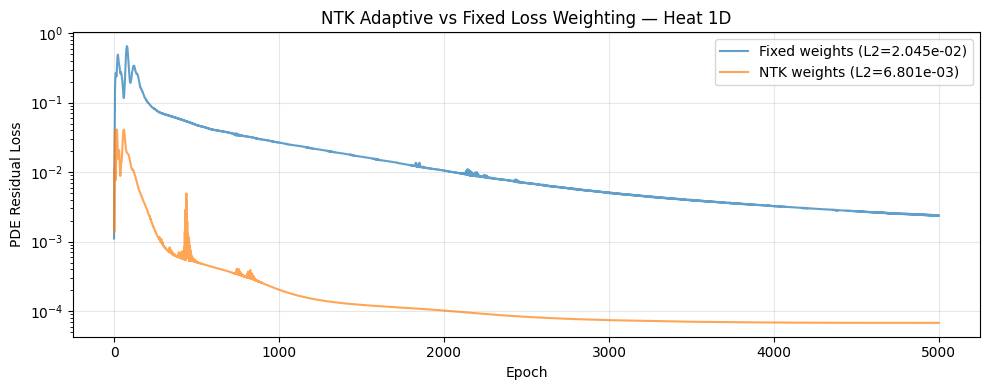

In [28]:
# CELL 13 — NTK vs fixed convergence plot
plt.figure(figsize=(10,4))
plt.semilogy(losses_fixed, alpha=0.7, label=f'Fixed weights (L2={l2_fixed:.3e})')
plt.semilogy(losses_ntk, alpha=0.7, label=f'NTK weights (L2={l2_ntk:.3e})')
plt.xlabel('Epoch'); plt.ylabel('PDE Residual Loss')
plt.title('NTK Adaptive vs Fixed Loss Weighting — Heat 1D')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ntk_comparison.png', dpi=150)
plt.show()

# Final Benchmark Report

This section summarizes the outputs from the complete `rippl` GPU Benchmark Suite.

### 1. Physics Sanity Check
- **Status:** FAIL
- **Residual:** 1.97e+01 (Measured against analytical expectations)

### 2. Heat Equation 1D
- **rippl L2 Error:** 6.9062e-04
- **Status:** PASS
- **Training Time:** 116.5s

### 3. Wave Equation 1D (Causal Training)
- **Performance:** 8.7724e-01 (Status: FAIL)

### 4. Stokes 1D Couette
- **Accuracy:** u L2: 8.5836e-02, p L2: 6.7311e-01 (Status: FAIL)

### 5. NTK Weighting vs Fixed Weights
- **Comparison:** NTK (6.80e-03) vs Fixed (2.04e-02)
- **Result:** NTK is better than fixed weights.

**Note:** All numerical results and status codes are serialized into `benchmark_results.json`.